In [27]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.stats import norm
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy import stats

import joblib

In [28]:
aapl = pd.read_csv("data/processed/AAPL_cleaned.csv")
aapl["date"] = pd.to_datetime(aapl["date"])
aapl["exdate"] = pd.to_datetime(aapl["exdate"])

print(aapl.shape)
aapl.head()

(838276, 19)


,secid,date,exdate,strike_price,best_bid,best_offer,volume,open_interest,optionid,close,moneyness (S/K),price,volatility,rate,days_to_maturity,T,last_dividend,frequency,q
0,101594,2020-08-31,2020-09-04,100.00,29.4,29.7,150,411,135212375,129.04,1.290400,29.55,0.375779,0.002148,4,0.010959,0.205,3,0.004766
1,101594,2020-08-31,2020-11-20,80.00,50.1,50.5,0,343,134244951,129.04,1.613000,50.30,0.375779,0.002148,81,0.221918,0.205,3,0.004766
2,101594,2020-08-31,2020-11-20,81.25,48.9,49.3,1,416,134244952,129.04,1.588185,49.10,0.375779,0.002148,81,0.221918,0.205,3,0.004766
3,101594,2020-08-31,2020-11-20,82.50,47.7,48.1,16,383,134244953,129.04,1.564121,47.90,0.375779,0.002148,81,0.221918,0.205,3,0.004766
4,101594,2020-08-31,2020-11-20,83.75,46.5,46.9,0,414,134244954,129.04,1.540776,46.70,0.375779,0.002148,81,0.221918,0.205,3,0.004766


Creating bins for moneyness to compute the error for each model

In [29]:
# ============================================================
# Shared settings and helpers
# ============================================================
BINS   = [0, 0.8, 0.95, 1.05, 1.2, 2, 5, 100]
LABELS = ["Deep OTM", "OTM", "ATM", "ITM", "Deep ITM", "Very Deep ITM", "Extreme ITM"]

def bucket_mae(df, preds):
    """MAE by moneyness bucket for BS and each model; last row = all options.
    df: DataFrame with 'price', 'bs_price', 'moneyness (S/K)'.
    preds: dict name -> predicted prices aligned with df."""
    t = pd.DataFrame({"bucket": pd.cut(df["moneyness (S/K)"], bins=BINS, labels=LABELS),
                      "BS": np.abs(df["price"].values - df["bs_price"].values)})
    for k, p in preds.items():
        t[k] = np.abs(df["price"].values - np.asarray(p))
    out = t.groupby("bucket", observed=True).mean()
    out.insert(0, "n", t.groupby("bucket", observed=True).size())
    out.loc["ALL"] = [len(t)] + list(t.drop(columns="bucket").mean())
    return out.astype({"n": int})

## 1. Black-Scholes benchmark (call formula)

The closed-form Black-Scholes price is computed for each option as the benchmark against which the machine learning models will later be compared. Since the analysis is restricted to call options, only the call formula is implemented:

C = S·e^(-qT)·N(d1) − K·e^(-rT)·N(d2)

d1 = [ln(S/K) + (r − q + σ²/2)T] / (σ√T)

d2 = d1 − σ√T

In [30]:
d1 = (
    np.log(aapl["close"] / aapl["strike_price"])
    + (aapl["rate"] - aapl["q"] + 0.5 * aapl["volatility"] ** 2) * aapl["T"]
) / (aapl["volatility"] * np.sqrt(aapl["T"]))

d2 = d1 - aapl["volatility"] * np.sqrt(aapl["T"])

In [31]:
aapl["bs_price"] = (
    aapl["close"] * np.exp(-aapl["q"] * aapl["T"]) * norm.cdf(d1)
    - aapl["strike_price"] * np.exp(-aapl["rate"] * aapl["T"]) * norm.cdf(d2)
)

aapl["bs_price"].describe()

count    838276.000000
mean         34.851495
std          42.635250
min           0.000000
25%           1.404682
50%          16.424608
75%          57.070649
max         253.989479
Name: bs_price, dtype: float64

In [32]:
aapl["bs_error"] = aapl["price"] - aapl["bs_price"]
aapl["bs_error_abs"] = np.abs(aapl["bs_error"])

print(aapl["bs_error"].describe())

count    838276.000000
mean          0.145050
std           1.815228
min         -26.296163
25%          -0.047267
50%           0.141726
75%           0.597371
max           8.431758
Name: bs_error, dtype: float64


In [33]:
print(aapl.nlargest(5, "bs_error")[["date", "moneyness (S/K)", "T", "volatility", "price", "bs_price"]])
print()
print(aapl.nsmallest(5, "bs_error")[["date", "moneyness (S/K)", "T", "volatility", "price", "bs_price"]])

             date  moneyness (S/K)    T  volatility   price   bs_price
709640 2024-12-19         1.019551  1.0    0.160031  32.925  24.493242
709642 2024-12-19         0.999160  1.0    0.160031  30.025  21.617085
709652 2024-12-19         0.979569  1.0    0.160031  27.375  18.973291
709639 2024-12-19         1.040792  1.0    0.160031  35.950  27.598717
709643 2024-12-19         0.960731  1.0    0.160031  24.825  16.561278

             date  moneyness (S/K)         T  volatility   price   bs_price
783813 2025-05-13         0.851720  0.852055    0.596494   9.825  36.121163
783117 2025-05-12         0.843160  0.854795    0.597661   8.925  35.190170
783116 2025-05-12         0.878292  0.854795    0.597661  12.025  38.209632
783812 2025-05-13         0.887208  0.852055    0.596494  13.075  39.204280
783814 2025-05-13         0.818962  0.852055    0.596494   7.275  33.283936


## 2. Dataset split

In [34]:
aapl = aapl.sort_values("date").reset_index(drop=True)

train_cutoff = aapl["date"].quantile(0.70)
val_cutoff = aapl["date"].quantile(0.85)

train = aapl[aapl["date"] <= train_cutoff]
val = aapl[(aapl["date"] > train_cutoff) & (aapl["date"] <= val_cutoff)]
test = aapl[aapl["date"] > val_cutoff]

print(f"Train: {len(train)} rows, {train['date'].min()} to {train['date'].max()}")
print(f"Validation: {len(val)} rows, {val['date'].min()} to {val['date'].max()}")
print(f"Test: {len(test)} rows, {test['date'].min()} to {test['date'].max()}")

Train: 587104 rows, 2020-08-31 00:00:00 to 2024-03-27 00:00:00
Validation: 125955 rows, 2024-03-28 00:00:00 to 2024-12-26 00:00:00
Test: 125217 rows, 2024-12-27 00:00:00 to 2025-08-29 00:00:00


In [35]:
feature_cols = ["moneyness (S/K)", "T", "rate", "q", "volatility"]
target_col = "price"

X_train, y_train = train[feature_cols], train[target_col]
X_val, y_val = val[feature_cols], val[target_col]
X_test, y_test = test[feature_cols], test[target_col]

print("Feature columns:", feature_cols)
print("Target column:", target_col)

Feature columns: ['moneyness (S/K)', 'T', 'rate', 'q', 'volatility']
Target column: price


The dataset is split chronologically by trading date rather than by random row sampling, to avoid look-ahead bias: the earliest ~70% of dates form the training set, the following ~15% the validation set, and the final ~15% the held-out test set. Feature selection follows Hutchinson, Lo and Poggio (1994), using moneyness (S/K) in place of S and K as separate inputs.

### 1.2 Diagnostic: Black-Scholes aggregate error and by moneyness bucket

Before introducing any machine learning model, the Black-Scholes benchmark error is broken down by moneyness bucket on the validation and test set. This step is diagnostic: it checks whether the very low *aggregate* Black-Scholes error (computed above) is genuinely representative, or whether it is an artifact of the dataset composition (e.g. a large share of deep in-the-money contracts, for which price is close to intrinsic value and therefore near-trivial to predict). This data will be needed to compare it with the other models. 

#### 1.2.1 Black-Scholes error on validation set

In [36]:
# Black-Scholes error on the validation set (benchmark for the exploratory phase)
bs_mae_val = np.abs(val["price"] - val["bs_price"]).mean()
bs_rmse_val = np.sqrt(((val["price"] - val["bs_price"]) ** 2).mean())

print(f"Black-Scholes — AAPL validation set ({len(val):,} options)")
print(f"MAE:  {bs_mae_val:.4f}")
print(f"RMSE: {bs_rmse_val:.4f}")

Black-Scholes — AAPL validation set (125,955 options)
MAE:  0.6151
RMSE: 1.0652


In [37]:
# Black-Scholes error by moneyness bucket — validation set
val_bs_check = val.copy()
val_bs_check["bs_error_abs"] = np.abs(val_bs_check["price"] - val_bs_check["bs_price"])
val_bs_check["moneyness_bucket"] = pd.cut(
    val_bs_check["moneyness (S/K)"],
    bins=[0, 0.8, 0.95, 1.05, 1.2, 2, 5, 100],
    labels=["Deep OTM", "OTM", "ATM", "ITM", "Deep ITM", "Very Deep ITM", "Extreme ITM"]
)

val_bs_check.groupby("moneyness_bucket", observed=True).agg(
    n_options=("bs_error_abs", "size"),
    bs_mae=("bs_error_abs", "mean"),
    median_price=("price", "median"),
)

,n_options,bs_mae,median_price
moneyness_bucket,,,
Deep OTM,20297,0.302312,0.1650
OTM,21772,0.834901,1.0250
ATM,14114,1.195201,8.8250
ITM,16250,0.943610,27.4750
Deep ITM,32936,0.496165,70.6250
Very Deep ITM,16442,0.226069,136.6000
Extreme ITM,4144,0.216732,193.1375


#### 1.2.2 Black-Scholes error on test set

In [38]:
# Black-Scholes aggregate error on the test set
bs_mae_test = np.abs(test["price"] - test["bs_price"]).mean()
bs_rmse_test = np.sqrt(((test["price"] - test["bs_price"]) ** 2).mean())

print(f"Black-Scholes — AAPL test set ({len(test):,} options)")
print(f"MAE:  {bs_mae_test:.4f}")
print(f"RMSE: {bs_rmse_test:.4f}")

Black-Scholes — AAPL test set (125,217 options)
MAE:  1.7956
RMSE: 3.8554


In [39]:
# Black-Scholes error by moneyness bucket — test set
test_check = test.copy()
test_check["bs_error_abs"] = np.abs(test_check["price"] - test_check["bs_price"])

bins = [0, 0.8, 0.95, 1.05, 1.2, 2, 5, 100]
labels = ["deep OTM", "OTM", "ATM", "ITM", "deep ITM", "very deep ITM", "extreme ITM"]
test_check["moneyness_bucket"] = pd.cut(test_check["moneyness (S/K)"], bins=bins, labels=labels)

bs_bucket_test = test_check.groupby("moneyness_bucket", observed=True).agg(
    n_options=("bs_error_abs", "size"),
    bs_mae=("bs_error_abs", "mean"),
    median_price=("price", "median"),
)
bs_bucket_test["bs_mae_over_price"] = bs_bucket_test["bs_mae"] / bs_bucket_test["median_price"]
bs_bucket_test

,n_options,bs_mae,median_price,bs_mae_over_price
moneyness_bucket,,,,
deep OTM,26376,2.090844,0.2000,10.454222
OTM,22324,2.635443,1.4650,1.798937
ATM,13178,2.830286,10.3625,0.273128
ITM,15059,2.222774,29.4000,0.075605
deep ITM,31571,1.107418,71.6500,0.015456
very deep ITM,11824,0.317590,137.0500,0.002317
extreme ITM,4885,0.279314,193.4500,0.001444


## 3. XGBoost
A gradient-boosted tree model (XGBoost) is trained on the chronological training set, using the validation set for early stopping to prevent overfitting. Default/simple hyperparameters are used for this initial baseline; tuning is deferred to a later iteration.

### 3.1.1 XGBoost - baseline model v1 - old

This first model (baseline) uses the same five inputs as the Black-Scholes benchmark, with the raw option price as target.

In [66]:
model = xgb.XGBRegressor(
    n_estimators=1000,
    early_stopping_rounds=50,
    eval_metric="rmse",
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print(f"Best iteration: {model.best_iteration}")
print(f"Best validation RMSE: {model.best_score:.4f}")

Best iteration: 242
Best validation RMSE: 10.7806


In [67]:
train_pred_baseline = model.predict(X_train)
val_pred = model.predict(X_val)

train_rmse = np.sqrt(mean_squared_error(y_train, train_pred_baseline))
train_mae = mean_absolute_error(y_train, train_pred_baseline)

val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
val_mae = mean_absolute_error(y_val, val_pred)
val_r2 = r2_score(y_val, val_pred)

print(f"Train RMSE: {train_rmse:.4f}   Validation RMSE: {val_rmse:.4f}   ratio: {val_rmse/train_rmse:.2f}x")
print(f"Train MAE:  {train_mae:.4f}   Validation MAE:  {val_mae:.4f}   ratio: {val_mae/train_mae:.2f}x")
print(f"Validation R²: {val_r2:.4f}")

Train RMSE: 0.5210   Validation RMSE: 10.7806   ratio: 20.69x
Train MAE:  0.2962   Validation MAE:  6.2027   ratio: 20.94x
Validation R²: 0.9624


In [68]:
# Baseline XGBoost — train vs validation error by moneyness bucket
bins = [0, 0.8, 0.95, 1.05, 1.2, 2, 5, 100]
labels = ["Deep OTM", "OTM", "ATM", "ITM", "Deep ITM", "Very Deep ITM", "Extreme ITM"]

# training side
train_check_baseline = train.copy()
train_check_baseline["xgb_baseline_pred"] = train_pred_baseline
train_check_baseline["xgb_train_error_abs"] = (train_check_baseline["price"] - train_check_baseline["xgb_baseline_pred"]).abs()
train_check_baseline["moneyness_bucket"] = pd.cut(train_check_baseline["moneyness (S/K)"], bins=bins, labels=labels)

train_bucket = train_check_baseline.groupby("moneyness_bucket", observed=True).agg(
    n_train=("xgb_train_error_abs", "size"),
    xgb_train_mae=("xgb_train_error_abs", "mean"),
)

# validation side (built here, no longer relies on a deleted cell)
val_check_baseline = val.copy()
val_check_baseline["xgb_baseline_pred"] = val_pred
val_check_baseline["xgb_baseline_error_abs"] = (val_check_baseline["price"] - val_check_baseline["xgb_baseline_pred"]).abs()
val_check_baseline["bs_error_abs"] = (val_check_baseline["price"] - val_check_baseline["bs_price"]).abs()
val_check_baseline["moneyness_bucket"] = pd.cut(val_check_baseline["moneyness (S/K)"], bins=bins, labels=labels)

val_bucket = val_check_baseline.groupby("moneyness_bucket", observed=True).agg(
    n_val=("bs_error_abs", "size"),
    bs_mae=("bs_error_abs", "mean"),
    xgb_val_mae=("xgb_baseline_error_abs", "mean"),
)

# combine
baseline_bucket_summary = train_bucket.join(val_bucket)
baseline_bucket_summary["overfit_ratio"] = (
    baseline_bucket_summary["xgb_val_mae"] / baseline_bucket_summary["xgb_train_mae"]
)
baseline_bucket_summary

,n_train,xgb_train_mae,n_val,bs_mae,xgb_val_mae,overfit_ratio
moneyness_bucket,,,,,,
Deep OTM,105285,0.116390,20297,0.302312,0.260151,2.235167
OTM,95876,0.201268,21772,0.834901,0.729044,3.622261
ATM,73909,0.319483,14114,1.195201,1.785584,5.588986
ITM,87994,0.313444,16250,0.943610,3.661987,11.683073
Deep ITM,144521,0.347908,32936,0.496165,8.865658,25.482757
Very Deep ITM,74966,0.408704,16442,0.226069,17.097240,41.832808
Extreme ITM,4553,2.249438,4144,0.216732,24.683062,10.972990


### 3.1.2 XGBoost - baseline v1 - thesis relevant

In [69]:
feature_cols_v1b = ["moneyness (S/K)", "strike_price", "T", "rate", "q", "volatility"]

X_train_v1b, y_train_v1b = train[feature_cols_v1b], train["price"]
X_val_v1b,   y_val_v1b   = val[feature_cols_v1b],   val["price"]

# sanity checks: positive prices and strikes (needed later for log targets)
for name, d in [("train", train), ("val", val), ("test", test)]:
    assert (d["price"] > 0).all() and (d["strike_price"] > 0).all(), name
print("Features:", feature_cols_v1b)

Features: ['moneyness (S/K)', 'strike_price', 'T', 'rate', 'q', 'volatility']


In [70]:
model_v1b = xgb.XGBRegressor(
    n_estimators=1000,
    early_stopping_rounds=50,
    eval_metric="rmse",
    random_state=42
)
model_v1b.fit(X_train_v1b, y_train_v1b, eval_set=[(X_val_v1b, y_val_v1b)], verbose=False)

print(f"Best iteration: {model_v1b.best_iteration}")
print(f"Objective: {model_v1b.get_params()['objective']}")   # None -> default reg:squarederror

Best iteration: 287
Objective: reg:squarederror


In [71]:
train_pred_v1b = model_v1b.predict(X_train_v1b)
val_pred_v1b   = model_v1b.predict(X_val_v1b)

def summary(y, p):
    return np.sqrt(mean_squared_error(y, p)), mean_absolute_error(y, p)

tr_rmse, tr_mae = summary(y_train_v1b, train_pred_v1b)
va_rmse, va_mae = summary(y_val_v1b, val_pred_v1b)
old_rmse, old_mae = summary(y_val, val_pred)                  # old v1 (3.1.1)

print(f"v1b  Train RMSE={tr_rmse:.4f} MAE={tr_mae:.4f}")
print(f"v1b  Val   RMSE={va_rmse:.4f} MAE={va_mae:.4f}  (ratio val/train RMSE: {va_rmse/tr_rmse:.2f}x)")
print(f"v1   Val   RMSE={old_rmse:.4f} MAE={old_mae:.4f}  (old baseline, no K)")
print(f"BS   Val   RMSE={bs_rmse_val:.4f} MAE={bs_mae_val:.4f}")
print("Negative predictions on val:", (val_pred_v1b < 0).sum())

v1b  Train RMSE=0.3726 MAE=0.2692
v1b  Val   RMSE=11.5183 MAE=6.6279  (ratio val/train RMSE: 30.91x)
v1   Val   RMSE=10.7806 MAE=6.2027  (old baseline, no K)
BS   Val   RMSE=1.0652 MAE=0.6151
Negative predictions on val: 5552


In [72]:
bins = [0, 0.8, 0.95, 1.05, 1.2, 2, 5, 100]
labels = ["Deep OTM", "OTM", "ATM", "ITM", "Deep ITM", "Very Deep ITM", "Extreme ITM"]

v1b_check = val.copy()
v1b_check["bs_err"]  = np.abs(v1b_check["price"] - v1b_check["bs_price"])
v1b_check["v1_err"]  = np.abs(v1b_check["price"] - val_pred)
v1b_check["v1b_err"] = np.abs(v1b_check["price"] - val_pred_v1b)
v1b_check["bucket"]  = pd.cut(v1b_check["moneyness (S/K)"], bins=bins, labels=labels)

v1b_bucket = v1b_check.groupby("bucket", observed=True).agg(
    n=("bs_err", "size"),
    median_price=("price", "median"),
    bs_mae=("bs_err", "mean"),
    v1_mae=("v1_err", "mean"),
    v1b_mae=("v1b_err", "mean"),
)
v1b_bucket["v1b_vs_bs"] = v1b_bucket["v1b_mae"] / v1b_bucket["bs_mae"]
v1b_bucket.round(3)

,n,median_price,bs_mae,v1_mae,v1b_mae,v1b_vs_bs
bucket,,,,,,
Deep OTM,20297,0.165,0.302,0.260,0.243,0.805
OTM,21772,1.025,0.835,0.729,0.910,1.090
ATM,14114,8.825,1.195,1.786,1.977,1.654
ITM,16250,27.475,0.944,3.662,3.600,3.815
Deep ITM,32936,70.625,0.496,8.866,9.311,18.766
Very Deep ITM,16442,136.600,0.226,17.097,18.377,81.291
Extreme ITM,4144,193.138,0.217,24.683,27.713,127.867


In [35]:
for col in ["strike_price", "close", "price"]:
    tr_max = train[col].max()
    print(f"{col:13s} train max={tr_max:8.2f}  val max={val[col].max():8.2f}  "
          f"share of val above train max={(val[col] > tr_max).mean():.2%}")

strike_price  train max=  380.00  val max=  400.00  share of val above train max=0.03%
close         train max=  198.11  val max=  259.02  share of val above train max=74.35%
price         train max=  190.18  val max=  254.55  share of val above train max=1.94%


In [111]:
print("v1b negative predictions:", (val_pred_v1b < 0).sum())
print("v1b min prediction:", val_pred_v1b.min())

v1b negative predictions: 5552
v1b min prediction: -0.7757372


### 3.2.2 NEW Experiment (v2): S/K, K, log-transformed target


In [80]:
feature_cols_v2b = ["moneyness (S/K)", "strike_price", "T", "rate", "q", "volatility"]

X_train_v2b, X_val_v2b = train[feature_cols_v2b], val[feature_cols_v2b]
y_train_v2b = np.log1p(train["price"].values)
y_val_v2b   = np.log1p(val["price"].values)

model_v2b = xgb.XGBRegressor(
    n_estimators=1000,
    early_stopping_rounds=50,
    eval_metric="rmse",
    random_state=42
)
model_v2b.fit(X_train_v2b, y_train_v2b, eval_set=[(X_val_v2b, y_val_v2b)], verbose=False)

val_pred_v2b = np.expm1(model_v2b.predict(X_val_v2b))

print(f"Best iteration: {model_v2b.best_iteration}")
print(f"v2b val RMSE={np.sqrt(mean_squared_error(val['price'], val_pred_v2b)):.4f}  "
      f"MAE={mean_absolute_error(val['price'], val_pred_v2b):.4f}  neg={(val_pred_v2b < 0).sum()}")

Best iteration: 54
v2b val RMSE=11.5080  MAE=6.5926  neg=2384


In [81]:
bins = [0, 0.8, 0.95, 1.05, 1.2, 2, 5, 100]
labels = ["Deep OTM", "OTM", "ATM", "ITM", "Deep ITM", "Very Deep ITM", "Extreme ITM"]

v2b_check = val.copy()
v2b_check["bs_err"]  = np.abs(v2b_check["price"] - v2b_check["bs_price"])
v2b_check["v2_err"]  = np.abs(v2b_check["price"] - val_pred_v2)     # old, log1p
v2b_check["v2b_err"] = np.abs(v2b_check["price"] - val_pred_v2b)    # new, log
v2b_check["bucket"]  = pd.cut(v2b_check["moneyness (S/K)"], bins=bins, labels=labels)

v2b_check.groupby("bucket", observed=True).agg(
    n=("bs_err", "size"),
    bs_mae=("bs_err", "mean"),
    v2_mae=("v2_err", "mean"),
    v2b_mae=("v2b_err", "mean"),
).round(3)

,n,bs_mae,v2_mae,v2b_mae
bucket,,,,
Deep OTM,20297,0.302,0.408,0.251
OTM,21772,0.835,2.125,0.736
ATM,14114,1.195,7.114,1.797
ITM,16250,0.944,17.133,3.406
Deep ITM,32936,0.496,23.699,9.462
Very Deep ITM,16442,0.226,24.065,18.376
Extreme ITM,4144,0.217,20.796,27.698


### 3.3 Experiment (v3): Moneyness input + normalized output

In [83]:
feature_cols_v3 = ["moneyness (S/K)", "T", "rate", "q", "volatility"]

X_train_v3, X_val_v3 = train[feature_cols_v3], val[feature_cols_v3]
y_train_v3 = train["price"].values / train["strike_price"].values
y_val_v3   = val["price"].values / val["strike_price"].values

model_v3 = xgb.XGBRegressor(
    n_estimators=1000,
    early_stopping_rounds=50,
    eval_metric="rmse",
    random_state=42
)
model_v3.fit(X_train_v3, y_train_v3, eval_set=[(X_val_v3, y_val_v3)], verbose=False)

val_pred_v3 = model_v3.predict(X_val_v3) * val["strike_price"].values   # back to price

print(f"Best iteration: {model_v3.best_iteration}")
print(f"v3 val RMSE={np.sqrt(mean_squared_error(val['price'], val_pred_v3)):.4f}  "
      f"MAE={mean_absolute_error(val['price'], val_pred_v3):.4f}  neg={(val_pred_v3 < 0).sum()}")

Best iteration: 8
v3 val RMSE=38.6705  MAE=8.6159  neg=0


In [84]:
bucket_mae(val, {"v2b log1pC (S/K+K)": val_pred_v2b,
                 "v3 C/K (S/K)":       val_pred_v3}).round(3)

,n,BS,v2b log1pC (S/K+K),v3 C/K (S/K)
bucket,,,,
Deep OTM,20297.0,0.302,0.251,5.942
OTM,21772.0,0.835,0.736,4.893
ATM,14114.0,1.195,1.797,4.260
ITM,16250.0,0.944,3.406,2.720
Deep ITM,32936.0,0.496,9.462,1.400
Very Deep ITM,16442.0,0.226,18.376,4.873
Extreme ITM,4144.0,0.217,27.698,151.427
ALL,125955.0,0.615,6.593,8.616


### 3.4 Best configuration (v4): moneyness input + log-transformed target

This configuration keeps the same five inputs as the baseline (moneyness in place of S and K separately) but switches the target to `log1p(price)`, as in v2. Of the configurations tested, this is the one retained as the current XGBoost baseline for further work (hyperparameter tuning, SPX comparison, etc.).

In [88]:
feature_cols_v4 = ["moneyness (S/K)", "T", "rate", "q", "volatility"]
X_train_v4, X_val_v4 = train[feature_cols_v4], val[feature_cols_v4]

y_train_v4 = np.log(train["price"].values / train["strike_price"].values)
y_val_v4   = np.log(val["price"].values / val["strike_price"].values)

model_v4 = xgb.XGBRegressor(
    n_estimators=1000, 
    early_stopping_rounds=50, 
    eval_metric="rmse", 
    random_state=42
)
model_v4.fit(X_train_v4, y_train_v4, eval_set=[(X_val_v4, y_val_v4)], verbose=False)

val_pred_v4 = np.exp(model_v4.predict(X_val_v4)) * val["strike_price"].values

v4_check = val.copy()
v4_check["xgb_v4_error_abs"] = np.abs(v4_check["price"] - val_pred_v4)
v4_check["xgb_v4_pct_error"] = v4_check["xgb_v4_error_abs"] / v4_check["price"] * 100
v4_check["bs_error_abs"] = np.abs(v4_check["price"] - v4_check["bs_price"])
v4_check["bs_pct_error"] = v4_check["bs_error_abs"] / v4_check["price"] * 100

v4_check["moneyness_bucket"] = pd.cut(
    v4_check["moneyness (S/K)"],
    bins=[0, 0.8, 0.95, 1.05, 1.2, 2, 5, 100],
    labels=["Deep OTM", "OTM", "ATM", "ITM", "Deep ITM", "Very Deep ITM", "Extreme ITM"]
)

print(v4_check.groupby("moneyness_bucket", observed=True)[["bs_error_abs", "xgb_v4_error_abs", "bs_pct_error", "xgb_v4_pct_error"]].mean())

                  bs_error_abs  xgb_v4_error_abs  bs_pct_error  \
moneyness_bucket                                                 
Deep OTM              0.302312          0.207773     77.758907   
OTM                   0.834901          0.583540     56.455658   
ATM                   1.195201          1.051356     19.336024   
ITM                   0.943610          0.929340      3.335738   
Deep ITM              0.496165          3.469230      0.784742   
Very Deep ITM         0.226069         10.462377      0.166602   
Extreme ITM           0.216732        100.713694      0.113283   

                  xgb_v4_pct_error  
moneyness_bucket                    
Deep OTM                 37.510701  
OTM                      44.949866  
ATM                      23.614189  
ITM                       3.503281  
Deep ITM                  4.483625  
Very Deep ITM             7.397820  
Extreme ITM              52.382935  


In [89]:
bucket_mae(val, {"v2b log1pC (S/K+K)": val_pred_v2b,
                 "v3 C/K (S/K)":       val_pred_v3,
                 "v4 logC/K (S/K)":    val_pred_v4}).round(3)

,n,BS,v2b log1pC (S/K+K),v3 C/K (S/K),v4 logC/K (S/K)
bucket,,,,,
Deep OTM,20297.0,0.302,0.251,5.942,0.208
OTM,21772.0,0.835,0.736,4.893,0.584
ATM,14114.0,1.195,1.797,4.260,1.051
ITM,16250.0,0.944,3.406,2.720,0.929
Deep ITM,32936.0,0.496,9.462,1.400,3.469
Very Deep ITM,16442.0,0.226,18.376,4.873,10.462
Extreme ITM,4144.0,0.217,27.698,151.427,100.714
ALL,125955.0,0.615,6.593,8.616,5.959


### 3.6 Comparison on validation set for the three configurations

In [112]:
bucket_mae(val, {"v1b C (S/K+K)":      val_pred_v1b,
                 "v2b log1pC (S/K+K)": val_pred_v2b,
                 "v3 C/K (S/K)":       val_pred_v3,
                 "v4 logC/K (S/K)":    val_pred_v4}).round(3)

,n,BS,v1b C (S/K+K),v2b log1pC (S/K+K),v3 C/K (S/K),v4 logC/K (S/K)
bucket,,,,,,
Deep OTM,20297.0,0.302,0.243,0.251,5.942,0.208
OTM,21772.0,0.835,0.910,0.736,4.893,0.584
ATM,14114.0,1.195,1.977,1.797,4.260,1.051
ITM,16250.0,0.944,3.600,3.406,2.720,0.929
Deep ITM,32936.0,0.496,9.311,9.462,1.400,3.469
Very Deep ITM,16442.0,0.226,18.377,18.376,4.873,10.462
Extreme ITM,4144.0,0.217,27.713,27.698,151.427,100.714
ALL,125955.0,0.615,6.628,6.593,8.616,5.959


## Systematic hyperparameter tuning via rolling-window cross-validation

Grid search over XGBoost hyperparameters, evaluated with rolling-window (walk-forward) cross-validation to preserve chronological ordering and avoid look-ahead bias, per Ruf & Wang (2021). Cross-validation is performed only within the combined train+validation period (85% of dates); the held-out test set remains untouched until the final evaluation.

Window design: 18-month training window, 3-month validation window, 3-month step (non-overlapping validation folds). Features and target follow the best configuration found above (v6): moneyness, T, rate, q, volatility, with `log1p(price)` as target.

In [40]:
# Build rolling-window folds: 24-month train, 6-month validation, 6-month step
train_val = pd.concat([train, val]).sort_values("date").reset_index(drop=True)

start_date = train_val["date"].min()
end_date = train_val["date"].max()

fold_boundaries = []
fold_start = start_date

In [45]:
print("AAPL:", train_val["moneyness (S/K)"].quantile(0.99))


AAPL: 5.353404631578961


In [41]:
for col in ["close", "strike_price", "price"]:
    tr_max = train_val[col].max()
    te_max = test[col].max()
    share = (test[col] > tr_max).mean()
    print(f"{col:13s} train+val max={tr_max:9.2f}  test max={te_max:9.2f}  "
          f"share of test above={share:.1%}")

itm = test[test["moneyness (S/K)"] > 1.2]
print(f"\ndeep ITM and beyond: {len(itm):,} observations")
for col in ["close", "strike_price", "price"]:
    tr_max = train_val[col].max()
    print(f"{col:13s} share above train+val max={(itm[col] > tr_max).mean():.1%}")

close         train+val max=   259.02  test max=   255.59  share of test above=0.0%
strike_price  train+val max=   400.00  test max=   400.00  share of test above=0.0%
price         train+val max=   254.55  test max=   250.62  share of test above=0.0%

deep ITM and beyond: 48,280 observations
close         share above train+val max=0.0%
strike_price  share above train+val max=0.0%
price         share above train+val max=0.0%


In [42]:
# la moneyness stessa: è dentro il range di train+val?
print("moneyness train+val max:", train_val["moneyness (S/K)"].max())
print("moneyness test max:", test["moneyness (S/K)"].max())
print("share of test moneyness above train+val max:", (test["moneyness (S/K)"] > train_val["moneyness (S/K)"].max()).mean())

moneyness train+val max: 51.804
moneyness test max: 51.118
share of test moneyness above train+val max: 0.0


In [43]:
print("median close - train+val:", train_val["close"].median(), " | test:", test["close"].median())
print("median price - train+val:", train_val["price"].median(), " | test:", test["price"].median())
print("median moneyness - train+val:", train_val["moneyness (S/K)"].median(), " | test:", test["moneyness (S/K)"].median())

# e nella sola regione deep ITM
itm_tv = train_val[train_val["moneyness (S/K)"] > 1.2]
itm_te = test[test["moneyness (S/K)"] > 1.2]
print("\ndeep ITM only:")
print("median close - train+val:", itm_tv["close"].median(), " | test:", itm_te["close"].median())
print("median price - train+val:", itm_tv["price"].median(), " | test:", itm_te["price"].median())

median close - train+val: 157.96  | test: 214.0
median price - train+val: 16.1  | test: 20.475
median moneyness - train+val: 1.0808571428571427  | test: 1.0566511627906976

deep ITM only:
median close - train+val: 162.41  | test: 216.98
median price - train+val: 67.675  | test: 91.0


In [90]:
# Build rolling-window folds: 24-month train, 6-month validation, 6-month step
train_val = pd.concat([train, val]).sort_values("date").reset_index(drop=True)

start_date = train_val["date"].min()
end_date = train_val["date"].max()

fold_boundaries = []
fold_start = start_date

while True:
    train_end = fold_start + pd.DateOffset(months=24)
    if train_end >= end_date:
        break

    val_end = min(train_end + pd.DateOffset(months=6), end_date)
    fold_boundaries.append((fold_start, train_end, val_end))

    if val_end >= end_date:
        break

    fold_start = fold_start + pd.DateOffset(months=6)

print(f"Number of folds: {len(fold_boundaries)}")
for i, (ts, te, ve) in enumerate(fold_boundaries):
    n_val_days = (ve - te).days
    print(f"Fold {i+1}: train [{ts.date()} -> {te.date()}], val [{te.date()} -> {ve.date()}] ({n_val_days} days)")

Number of folds: 5
Fold 1: train [2020-08-31 -> 2022-08-31], val [2022-08-31 -> 2023-02-28] (181 days)
Fold 2: train [2021-02-28 -> 2023-02-28], val [2023-02-28 -> 2023-08-28] (181 days)
Fold 3: train [2021-08-28 -> 2023-08-28], val [2023-08-28 -> 2024-02-28] (184 days)
Fold 4: train [2022-02-28 -> 2024-02-28], val [2024-02-28 -> 2024-08-28] (182 days)
Fold 5: train [2022-08-28 -> 2024-08-28], val [2024-08-28 -> 2024-12-26] (120 days)


In [91]:
# Define hyperparameter grid for XGBoost
import itertools

param_grid = {
    "max_depth": [5, 7, 9, 10],
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators": [100, 300, 500],
    "subsample": [0.8, 1.0],
    # "colsample_bytree": [0.8, 1.0]
}

param_combinations = list(itertools.product(*param_grid.values()))
param_names = list(param_grid.keys())

print(f"Total combinations to test: {len(param_combinations)}")
print(f"Total model fits: {len(param_combinations) * len(fold_boundaries)}")

Total combinations to test: 72
Total model fits: 360


In [18]:
# Run rolling-window CV grid search — v4: target log(C/K)
cv_feature_cols = ["moneyness (S/K)", "T", "rate", "q", "volatility"]
cv_target_col = "price"

cv_results = []


In [92]:
# Run rolling-window CV grid search — v4: target log(C/K)
cv_feature_cols = ["moneyness (S/K)", "T", "rate", "q", "volatility"]
cv_target_col = "price"

cv_results = []

for combo in param_combinations:
    params = dict(zip(param_names, combo))
    fold_rmses = []

    for (fold_train_start, fold_train_end, fold_val_end) in fold_boundaries:
        fold_train = train_val[
            (train_val["date"] >= fold_train_start) & (train_val["date"] < fold_train_end)
        ]
        fold_val = train_val[
            (train_val["date"] >= fold_train_end) & (train_val["date"] < fold_val_end)
        ]

        X_fold_train = fold_train[cv_feature_cols]
        y_fold_train_log = np.log(fold_train[cv_target_col] / fold_train["strike_price"])   # changed
        X_fold_val = fold_val[cv_feature_cols]
        y_fold_val = fold_val[cv_target_col]

        fold_model = xgb.XGBRegressor(**params, random_state=42, n_jobs=-1)
        fold_model.fit(X_fold_train, y_fold_train_log)

        y_fold_pred = np.exp(fold_model.predict(X_fold_val)) * fold_val["strike_price"].values   # changed
        fold_rmse = np.sqrt(mean_squared_error(y_fold_val, y_fold_pred))
        fold_rmses.append(fold_rmse)

    cv_results.append({
        **params,
        "mean_rmse": np.mean(fold_rmses),
        "std_rmse": np.std(fold_rmses)
    })

cv_results_df = pd.DataFrame(cv_results).sort_values("mean_rmse")
cv_results_df.head(10)

,max_depth,learning_rate,n_estimators,subsample,mean_rmse,std_rmse
5,5,0.01,500,1.0,8.970627,6.643058
7,5,0.05,100,1.0,9.010053,6.689258
6,5,0.05,100,0.8,9.027206,6.855059
4,5,0.01,500,0.8,9.028873,6.733391
13,5,0.10,100,1.0,9.255881,7.771735
12,5,0.10,100,0.8,9.359862,8.041794
8,5,0.05,300,0.8,9.629245,8.506586
9,5,0.05,300,1.0,9.677588,8.427052
24,7,0.05,100,0.8,10.150357,9.443032
30,7,0.10,100,0.8,10.193602,9.876257


Note that the standard deviation of the RMSE across folds is high, about 6,64 / 8,97 ≈ 74% of the mean. This means that the performance of the model depends strongly on the market period used as validation fold. In the next cell we analyze the error fold by fold for the top 5 combinations of parameters.

In [93]:
# Fold-by-fold RMSE for the top N hyperparameter combinations
top_n = 5
top_combos = cv_results_df.head(top_n)[param_names].to_dict("records")

detailed_results = []

for params in top_combos:
    fold_rmses = []

    for (fold_train_start, fold_train_end, fold_val_end) in fold_boundaries:
        fold_train = train_val[
            (train_val["date"] >= fold_train_start) & (train_val["date"] < fold_train_end)
        ]
        fold_val = train_val[
            (train_val["date"] >= fold_train_end) & (train_val["date"] < fold_val_end)
        ]

        X_fold_train = fold_train[cv_feature_cols]
        y_fold_train_log = np.log(fold_train[cv_target_col] / fold_train["strike_price"])   # changed
        X_fold_val = fold_val[cv_feature_cols]
        y_fold_val = fold_val[cv_target_col]

        fold_model = xgb.XGBRegressor(**params, random_state=42, n_jobs=-1)
        fold_model.fit(X_fold_train, y_fold_train_log)

        y_fold_pred = np.exp(fold_model.predict(X_fold_val)) * fold_val["strike_price"].values   # changed
        fold_rmse = np.sqrt(mean_squared_error(y_fold_val, y_fold_pred))
        fold_rmses.append(fold_rmse)

    detailed_results.append({**params, **{f"fold_{i+1}_rmse": r for i, r in enumerate(fold_rmses)}})

detailed_df = pd.DataFrame(detailed_results)
detailed_df

,max_depth,learning_rate,n_estimators,subsample,fold_1_rmse,fold_2_rmse,fold_3_rmse,fold_4_rmse,fold_5_rmse
0,5,0.01,500,1.0,1.510131,1.995879,9.572425,19.073314,12.701387
1,5,0.05,100,1.0,1.600117,1.924992,9.519741,19.209844,12.795568
2,5,0.05,100,0.8,1.520905,1.741089,9.519202,19.571086,12.783749
3,5,0.01,500,0.8,1.516679,1.966790,9.583414,19.340461,12.737021
4,5,0.10,100,1.0,0.892367,1.442280,9.253313,21.823867,12.867579


In [94]:
aapl.groupby(aapl["date"].dt.to_period("M"))["volatility"].mean().loc["2024-02":"2024-12"]

date
2024-02    0.192166
2024-03    0.186249
2024-04    0.215737
2024-05    0.257983
2024-06    0.271440
2024-07    0.273413
2024-08    0.266121
2024-09    0.226269
2024-10    0.215182
2024-11    0.203785
2024-12    0.160666
Freq: M, Name: volatility, dtype: float64

In [19]:
# Final model: retrain on full train+validation with best hyperparameters from CV (v4: log(C/K))
best_params = {"max_depth": 5, "learning_rate": 0.01, "n_estimators": 500, "subsample": 1.0}
# ensure correct types (grid values may come back as numpy types)
best_params = {k: (int(v) if k in ["max_depth", "n_estimators"] else float(v)) for k, v in best_params.items()}

print("Best hyperparameters selected via rolling-window CV:")
print(best_params)

final_model = xgb.XGBRegressor(**best_params, random_state=42, n_jobs=-1)

X_train_val = train_val[cv_feature_cols]
y_train_val_log = np.log(train_val[cv_target_col] / train_val["strike_price"])   # changed

final_model.fit(X_train_val, y_train_val_log)

Best hyperparameters selected via rolling-window CV:
{'max_depth': 5, 'learning_rate': 0.01, 'n_estimators': 500, 'subsample': 1.0}


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [20]:
# Evaluate final model on the untouched test set — once
X_test = test[cv_feature_cols]
y_test = test[cv_target_col]

y_test_pred = np.exp(final_model.predict(X_test)) * test["strike_price"].values   # changed

test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"Final XGBoost (tuned) — Test set")
print(f"RMSE: {test_rmse:.4f}")
print(f"MAE:  {test_mae:.4f}")
print(f"R²:   {test_r2:.4f}")

Final XGBoost (tuned) — Test set
RMSE: 23.1489
MAE:  4.3502
R²:   0.8204


In [21]:
# Compare tuned XGBoost vs Black-Scholes on the test set, by moneyness bucket
test_check = test.copy()
test_check["xgb_final_pred"] = y_test_pred
test_check["xgb_final_error_abs"] = (test_check["price"] - test_check["xgb_final_pred"]).abs()
test_check["bs_error_abs"] = (test_check["price"] - test_check["bs_price"]).abs()

test_check["moneyness_bucket"] = pd.cut(test_check["moneyness (S/K)"], bins=BINS, labels=LABELS)

bucket_mae(test, {"XGB v4 logC/K": y_test_pred}).round(3)

,n,BS,XGB v4 logC/K
bucket,,,
Deep OTM,26376,2.091,0.204
OTM,22324,2.635,0.567
ATM,13178,2.830,1.182
ITM,15059,2.223,0.878
Deep ITM,31571,1.107,1.677
Very Deep ITM,11824,0.318,4.648
Extreme ITM,4885,0.279,79.830
ALL,125217,1.796,4.350


Training error:

In [22]:
# Train vs test error — AAPL XGBoost final model
X_train_val_check = train_val[cv_feature_cols]
y_train_val_check = train_val["price"]

train_pred_xgb = np.exp(final_model.predict(X_train_val_check)) * train_val["strike_price"].values   # changed
train_rmse_xgb = np.sqrt(mean_squared_error(y_train_val_check, train_pred_xgb))
train_mae_xgb = mean_absolute_error(y_train_val_check, train_pred_xgb)

print(f"AAPL XGBoost — Train (train+val): RMSE={train_rmse_xgb:.4f}, MAE={train_mae_xgb:.4f}")
print(f"AAPL XGBoost — Test:              RMSE={test_rmse:.4f}, MAE={test_mae:.4f}")
print(f"Ratio test/train RMSE: {test_rmse/train_rmse_xgb:.2f}x")

AAPL XGBoost — Train (train+val): RMSE=8.2646, MAE=1.4355
AAPL XGBoost — Test:              RMSE=23.1489, MAE=4.3502
Ratio test/train RMSE: 2.80x


In [105]:
# ============================================================
# Overfitting per bucket — AAPL XGBoost (train vs test)
# ============================================================

# MAE per bucket sul training set (train+val) e sul test
train_bucket = bucket_mae(train_val, {"xgb": train_pred_xgb})   # train_pred_xgb computed in the previous cell
test_bucket  = bucket_mae(test,      {"xgb": y_test_pred})

overfitting_by_bucket = pd.DataFrame({
    "n_train":   train_bucket["n"],
    "train_mae": train_bucket["xgb"],
    "n_test":    test_bucket["n"],
    "test_mae":  test_bucket["xgb"],
})
overfitting_by_bucket["ratio_test_vs_train"] = overfitting_by_bucket["test_mae"] / overfitting_by_bucket["train_mae"]

overfitting_by_bucket.round(3)

,n_train,train_mae,n_test,test_mae,ratio_test_vs_train
bucket,,,,,
Deep OTM,125582.0,0.135,26376.0,0.204,1.513
OTM,117648.0,0.358,22324.0,0.567,1.587
ATM,88023.0,0.689,13178.0,1.182,1.717
ITM,104244.0,0.572,15059.0,0.878,1.534
Deep ITM,177457.0,1.017,31571.0,1.677,1.649
Very Deep ITM,91408.0,3.099,11824.0,4.648,1.500
Extreme ITM,8697.0,43.759,4885.0,79.830,1.824
ALL,713059.0,1.435,125217.0,4.350,3.030


In [107]:
# Verify near-linearity of price vs intrinsic value (S-K) in the Deep ITM bucket
deep_itm = test_check[test_check["moneyness_bucket"] == "Deep ITM"].copy()

deep_itm["intrinsic_value"] = deep_itm["close"] - deep_itm["strike_price"]  # adjust column names if different

# Correlation between price and intrinsic value (should be very high if near-linear)
corr = deep_itm["price"].corr(deep_itm["intrinsic_value"])
print(f"Correlation between price and intrinsic value (Deep ITM): {corr:.4f}")

Correlation between price and intrinsic value (Deep ITM): 0.9901


In [108]:
# Compare how BS and XGBoost residuals relate to intrinsic value
deep_itm["bs_residual"] = deep_itm["price"] - deep_itm["bs_price"]
deep_itm["xgb_residual"] = deep_itm["price"] - deep_itm["xgb_final_pred"]

print("BS residual stats (Deep ITM):")
print(deep_itm["bs_residual"].describe())
print("\nXGBoost residual stats (Deep ITM):")
print(deep_itm["xgb_residual"].describe())

BS residual stats (Deep ITM):
count    31571.000000
mean         0.175946
std          1.963462
min        -16.268822
25%          0.029075
50%          0.402647
75%          1.004666
max          5.319632
Name: bs_residual, dtype: float64

XGBoost residual stats (Deep ITM):
count    31571.000000
mean         1.659575
std          1.160920
min         -1.229428
25%          0.789130
50%          1.487330
75%          2.364907
max          7.158491
Name: xgb_residual, dtype: float64


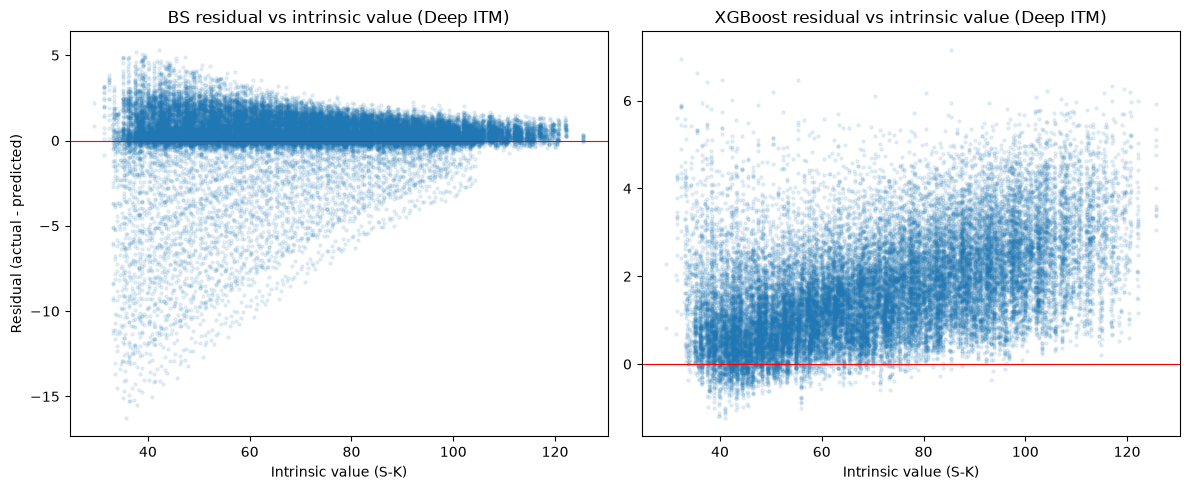

In [109]:
# Visualize: does XGBoost's error grow as intrinsic value grows?
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(deep_itm["intrinsic_value"], deep_itm["bs_residual"], alpha=0.1, s=5)
axes[0].axhline(0, color="red", linewidth=0.8)
axes[0].set_title("BS residual vs intrinsic value (Deep ITM)")
axes[0].set_xlabel("Intrinsic value (S-K)")
axes[0].set_ylabel("Residual (actual - predicted)")

axes[1].scatter(deep_itm["intrinsic_value"], deep_itm["xgb_residual"], alpha=0.1, s=5)
axes[1].axhline(0, color="red", linewidth=0.8)
axes[1].set_title("XGBoost residual vs intrinsic value (Deep ITM)")
axes[1].set_xlabel("Intrinsic value (S-K)")

plt.tight_layout()
plt.show()

L'errore di XGBoost sulle opzioni deep-ITM non è casuale ma sistematico: il modello sottostima progressivamente il prezzo al crescere del valore intrinseco, un pattern coerente con la nota incapacità dei modelli ad albero di estrapolare oltre il range dei valori target osservati in training. Black-Scholes, essendo una formula chiusa che converge analiticamente al valore intrinseco per costruzione, non soffre di questa limitazione."

## Save the final model

In [25]:
joblib.dump(final_model, "xgb_aapl_model.pkl")
joblib.dump({"test_pred": y_test_pred, "train_pred": train_pred_xgb, "best_params": best_params},
            "xgb_aapl_preds.pkl")
print("saved xgboost")

saved xgboost


Sanity checks

In [222]:
print(type(final_model))
print(final_model.get_booster().feature_names)

<class 'xgboost.sklearn.XGBRegressor'>
['moneyness (S/K)', 'T', 'rate', 'q', 'volatility']


In [223]:
print(train[["T", "rate", "q", "volatility", "strike_price"]].median())
print("\nmax moneyness in training:", train["moneyness (S/K)"].max())
print("min moneyness in training:", train["moneyness (S/K)"].min())

T                 0.194521
rate              0.008786
q                 0.004492
volatility        0.281015
strike_price    136.000000
dtype: float64

max moneyness in training: 39.036
min moneyness in training: 0.4167333333333333


In [224]:
print(train["moneyness (S/K)"].quantile([0.95, 0.99, 0.999]))
print("n options with moneyness > 5:", (train["moneyness (S/K)"] > 5).sum())
print("n options with moneyness > 10:", (train["moneyness (S/K)"] > 10).sum())

0.950    3.039652
0.990    4.752000
0.999    9.381270
Name: moneyness (S/K), dtype: float64
n options with moneyness > 5: 4553
n options with moneyness > 10: 551


In [225]:
# what does the model predict at moneyness values well inside the training range?
# compare against actual training prices in the same moneyness region
for lo, hi in [(0.95, 1.05), (1.15, 1.25), (1.9, 2.1), (2.9, 3.1), (4.5, 5.0), (9.0, 11.0)]:
    sub = train[(train["moneyness (S/K)"] >= lo) & (train["moneyness (S/K)"] <= hi)]
    print(f"moneyness {lo}-{hi}: n={len(sub):>6}  median price={sub['price'].median():>8.2f}  "
          f"median K={sub['strike_price'].median():>7.2f}  max price={sub['price'].max():>8.2f}")

moneyness 0.95-1.05: n= 73933  median price=    6.08  median K= 146.00  max price=   27.43
moneyness 1.15-1.25: n= 43733  median price=   26.58  median K= 125.00  max price=   49.42
moneyness 1.9-2.1: n= 17641  median price=   76.75  median K=  75.00  max price=  106.25
moneyness 2.9-3.1: n=  5686  median price=   99.79  median K=  50.00  max price=  134.68
moneyness 4.5-5.0: n=  2760  median price=  114.40  median K=  30.00  max price=  155.68
moneyness 9.0-11.0: n=    99  median price=  165.88  median K=  20.00  max price=  175.05
